# Dataset stats (current labels)


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing data/ and src/.")


PROJECT_ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"
LABELS_PATH = DATA_DIR / "labels.jsonl"
PLOTS_DIR = PROJECT_ROOT / "notebooks" / "data" / "dataset-stats"

LABEL_COLUMNS = ["trick", "execution_score", "key_foot", "person"]
AMBIGUITY_COLUMNS = ["ambiguous_score", "ambiguous_trick"]

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [2]:
def has_value(series: pd.Series) -> pd.Series:
    return series.notna() & series.astype("string").str.strip().ne("")


CLIP_RANGE_RE = re.compile(
    r"(\d{2})\.(\d{2})\.(\d{2})\.(\d{3})-(\d{2})\.(\d{2})\.(\d{2})\.(\d{3})"
)


def timestamp_parts_to_seconds(hours: str, minutes: str, seconds: str, millis: str) -> float:
    return int(hours) * 3600 + int(minutes) * 60 + int(seconds) + int(millis) / 1000


def parse_clip_duration(video: str):
    match = CLIP_RANGE_RE.search(Path(str(video)).name)
    if match is None:
        return pd.NA

    start = timestamp_parts_to_seconds(*match.groups()[:4])
    end = timestamp_parts_to_seconds(*match.groups()[4:])
    return end - start


def format_execution_score(series: pd.Series) -> pd.Series:
    scores = pd.to_numeric(series, errors="coerce").astype("Int64")
    return scores.astype("string")


def load_labels(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing labels file: {path}")

    df = pd.read_json(path, lines=True)

    for column in [*LABEL_COLUMNS, *AMBIGUITY_COLUMNS]:
        if column not in df.columns:
            df[column] = pd.NA

    for column in ["created_at", "updated_at"]:
        if column in df.columns:
            df[column] = pd.to_datetime(df[column], errors="coerce", utc=True)

    df["execution_score_label"] = format_execution_score(df["execution_score"])
    df["video_id"] = df["video"].map(lambda value: Path(str(value)).name if pd.notna(value) else pd.NA)
    df["clip_duration_seconds"] = df["video"].map(parse_clip_duration)
    df["has_ambiguous_score"] = has_value(df["ambiguous_score"])
    df["has_ambiguous_trick"] = has_value(df["ambiguous_trick"])
    return df


labels_df = load_labels(LABELS_PATH)
score_labels_df = labels_df.loc[has_value(labels_df["execution_score_label"])].copy()
complete_labels_df = labels_df.loc[
    has_value(labels_df["video"])
    & has_value(labels_df["trick"])
    & has_value(labels_df["execution_score_label"])
].copy()

summary_df = pd.DataFrame(
    [
        {"metric": "rows", "count": len(labels_df)},
        {"metric": "unique videos", "count": labels_df["video_id"].nunique()},
        {"metric": "rows with trick", "count": int(has_value(labels_df["trick"]).sum())},
        {"metric": "rows with execution score", "count": len(score_labels_df)},
        {"metric": "rows with clip duration", "count": int(labels_df["clip_duration_seconds"].notna().sum())},
        {"metric": "complete score rows", "count": len(complete_labels_df)},
        {"metric": "ambiguous score rows", "count": int(labels_df["has_ambiguous_score"].sum())},
        {"metric": "ambiguous trick rows", "count": int(labels_df["has_ambiguous_trick"].sum())},
    ]
)
display(summary_df)
display(labels_df.head())


,metric,count
0,rows,992
1,unique videos,992
2,rows with trick,992
3,rows with execution score,992
4,rows with clip duration,992
5,complete score rows,992
6,ambiguous score rows,180
7,ambiguous trick rows,16


,video,annotation_id,annotator,id,created_at,updated_at,lead_time,trick,key_foot,person,execution_score,ambiguous_score,ambiguous_trick,execution_score_label,video_id,clip_duration_seconds,has_ambiguous_score,has_ambiguous_trick
0,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2539,1,11356,2026-04-24 10:14:30.183499+00:00,2026-04-24 14:51:47.161333+00:00,175.263,soul,right,Henrikas,2,None,None,2,25-10-31 19-46-26 5688-00.00.09.834-00.00.13.8...,4.014,False,False
1,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2540,1,11357,2026-04-24 10:14:30.183555+00:00,2026-04-27 14:32:51.337725+00:00,101.921,soul,right,Max,2,ambiguous_score,None,2,25-10-31 19-46-26 5688-00.00.25.739-00.00.29.2...,3.517,True,False
2,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2541,1,11358,2026-04-24 10:14:30.183593+00:00,2026-04-24 14:52:06.121537+00:00,42.061,soul,left,Henrikas,2,None,None,2,25-10-31 19-46-26 5688-00.00.35.696-00.00.40.5...,4.869,False,False
3,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2542,1,11359,2026-04-24 10:14:30.183632+00:00,2026-04-24 14:52:15.995784+00:00,35.957,soul,left,Max,2,None,None,2,25-10-31 19-46-26 5688-00.00.46.631-00.00.52.7...,6.102,False,False
4,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2543,1,11360,2026-04-24 10:14:30.183671+00:00,2026-04-24 14:52:23.904837+00:00,33.589,soul,right,Henrikas,2,None,None,2,25-10-31 19-46-26 5688-00.00.55.431-00.00.59.2...,3.785,False,False


In [3]:
def save_plot(fig, name: str) -> Path:
    path = PLOTS_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


def value_counts_table(frame: pd.DataFrame, column: str, order=None, include_missing: bool = False) -> pd.DataFrame:
    series = frame[column]
    if include_missing:
        series = series.astype("string").fillna("(missing)")
        dropna = False
    else:
        dropna = True

    counts = series.value_counts(dropna=dropna)
    if order is not None:
        counts = counts.reindex(order, fill_value=0)

    counts_df = counts.rename_axis(column).reset_index(name="count")
    total = counts_df["count"].sum()
    counts_df["pct"] = (counts_df["count"] / total * 100).round(2) if total else 0
    return counts_df


def plot_count(frame: pd.DataFrame, column: str, name: str, *, order=None, include_missing=False, figsize=(8, 4), rotation=45):
    counts_df = value_counts_table(frame, column, order=order, include_missing=include_missing)

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=counts_df, x=column, y="count", order=counts_df[column].tolist(), ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.bar_label(ax.containers[0], padding=3)
    ax.tick_params(axis="x", rotation=rotation)
    save_plot(fig, name)
    plt.show()
    display(counts_df)
    return counts_df


rating_order = sorted(score_labels_df["execution_score_label"].dropna().unique(), key=int)
trick_order = labels_df["trick"].value_counts().index.tolist()


## Missing and ambiguous labels


,column,missing_count,missing_pct
0,trick,0,0.0
1,execution_score,0,0.0
2,key_foot,0,0.0
3,person,0,0.0


,label,rows_with_label,ambiguous_count,ambiguous_pct_of_labeled
0,execution_score,992,180,18.15
1,trick,992,16,1.61


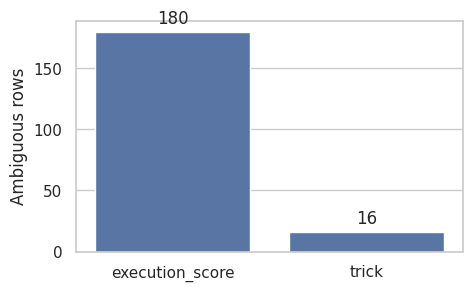

In [4]:
missing_df = pd.DataFrame(
    {
        "column": LABEL_COLUMNS,
        "missing_count": [int((~has_value(labels_df[column])).sum()) for column in LABEL_COLUMNS],
    }
)
missing_df["missing_pct"] = (missing_df["missing_count"] / len(labels_df) * 100).round(2)

ambiguity_df = pd.DataFrame(
    [
        {
            "label": "execution_score",
            "rows_with_label": len(score_labels_df),
            "ambiguous_count": int(labels_df["has_ambiguous_score"].sum()),
            "ambiguous_pct_of_labeled": round(labels_df["has_ambiguous_score"].sum() / len(score_labels_df) * 100, 2) if len(score_labels_df) else 0,
        },
        {
            "label": "trick",
            "rows_with_label": int(has_value(labels_df["trick"]).sum()),
            "ambiguous_count": int(labels_df["has_ambiguous_trick"].sum()),
            "ambiguous_pct_of_labeled": (labels_df["has_ambiguous_trick"].mean() * 100).round(2),
        },
    ]
)

display(missing_df)
display(ambiguity_df)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(data=ambiguity_df, x="label", y="ambiguous_count", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Ambiguous rows")
ax.bar_label(ax.containers[0], padding=3)
save_plot(fig, "ambiguous_label_counts")
plt.show()


## Trick distribution


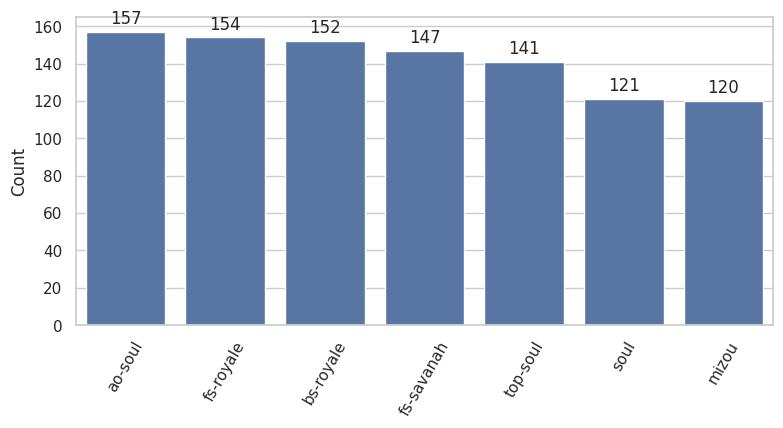

,trick,count,pct
0,ao-soul,157,15.83
1,fs-royale,154,15.52
2,bs-royale,152,15.32
3,fs-savanah,147,14.82
4,top-soul,141,14.21
5,soul,121,12.20
6,mizou,120,12.10


In [5]:
trick_counts = plot_count(
    labels_df,
    "trick",
    "trick_dist",
    order=trick_order,
    figsize=(9, 4),
    rotation=60,
)


## Ratings distribution


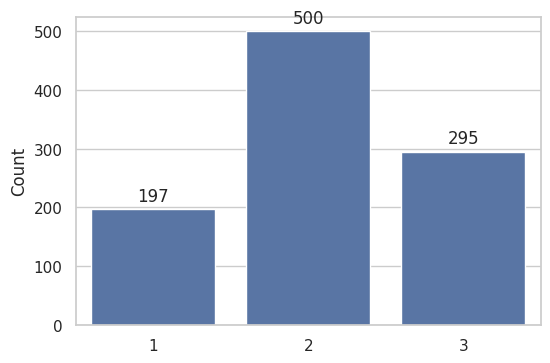

,execution_score_label,count,pct
0,1,197,19.86
1,2,500,50.4
2,3,295,29.74


In [6]:
score_counts = plot_count(
    score_labels_df,
    "execution_score_label",
    "ratings_dist",
    order=rating_order,
    figsize=(6, 4),
    rotation=0,
)


## Person distribution


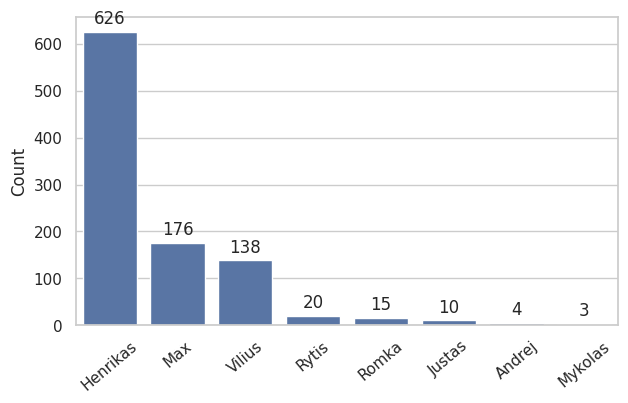

,person,count,pct
0,Henrikas,626,63.10
1,Max,176,17.74
2,Vilius,138,13.91
3,Rytis,20,2.02
4,Romka,15,1.51
5,Justas,10,1.01
6,Andrej,4,0.40
7,Mykolas,3,0.30


In [7]:
person_counts = plot_count(
    labels_df,
    "person",
    "person_dist",
    order=labels_df["person"].value_counts().index.tolist(),
    figsize=(7, 4),
    rotation=40,
)


## Key foot distribution


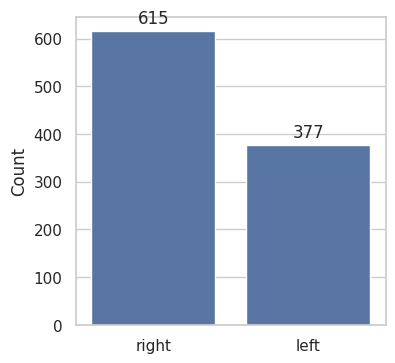

,key_foot,count,pct
0,right,615,62.0
1,left,377,38.0


In [8]:
key_foot_counts = plot_count(
    labels_df,
    "key_foot",
    "key_foot_dist",
    order=labels_df["key_foot"].value_counts().index.tolist(),
    figsize=(4, 4),
    rotation=0,
)


## Clip duration distribution


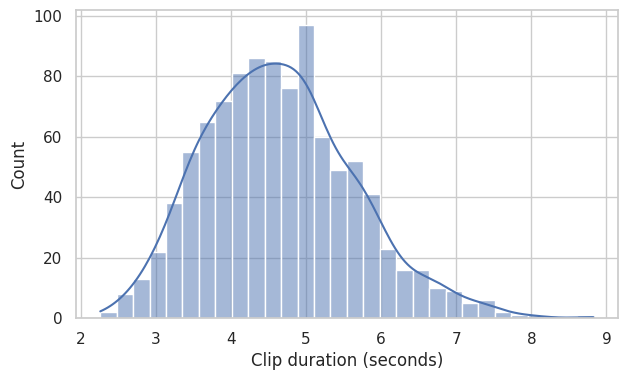

,clip_duration_seconds
count,992.000000
mean,4.649863
std,0.994989
min,2.262000
25%,3.926000
50%,4.583500
75%,5.248000
max,8.827000


In [9]:
clip_durations = labels_df["clip_duration_seconds"].dropna()
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(clip_durations, bins=30, kde=True, ax=ax)
ax.set_xlabel("Clip duration (seconds)")
ax.set_ylabel("Count")
save_plot(fig, "clip_duration_dist")
plt.show()

display(clip_durations.describe().to_frame(name="clip_duration_seconds"))


## Annotation lead time distribution


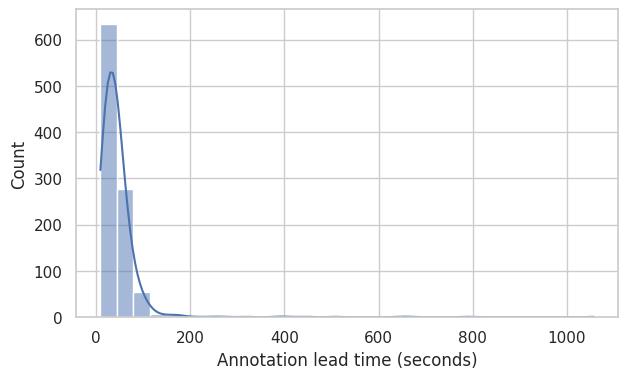

,lead_time_seconds
count,992.000000
mean,45.919016
std,61.429431
min,9.298000
25%,22.346000
50%,36.770500
75%,52.233000
max,1056.815000


In [10]:
lead_times = labels_df["lead_time"].dropna()
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(lead_times, bins=30, kde=True, ax=ax)
ax.set_xlabel("Annotation lead time (seconds)")
ax.set_ylabel("Count")
save_plot(fig, "annotation_lead_time_dist")
plt.show()

display(lead_times.describe().to_frame(name="lead_time_seconds"))


## Trick vs skater heatmap


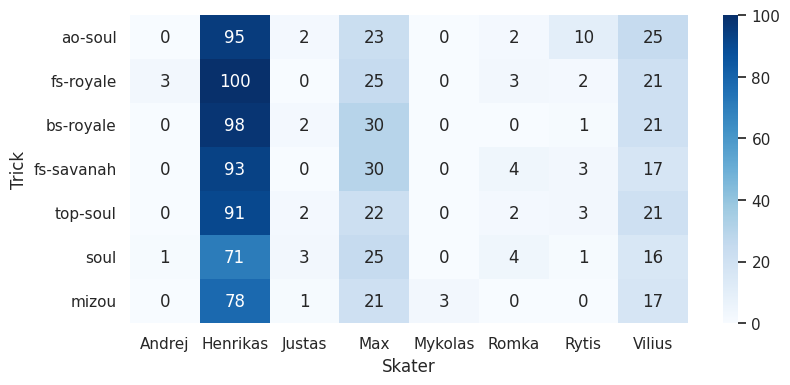

person,Andrej,Henrikas,Justas,Max,Mykolas,Romka,Rytis,Vilius
trick,,,,,,,,
ao-soul,0,95,2,23,0,2,10,25
fs-royale,3,100,0,25,0,3,2,21
bs-royale,0,98,2,30,0,0,1,21
fs-savanah,0,93,0,30,0,4,3,17
top-soul,0,91,2,22,0,2,3,21
soul,1,71,3,25,0,4,1,16
mizou,0,78,1,21,3,0,0,17


In [11]:
trick_person_counts = pd.crosstab(labels_df["trick"], labels_df["person"]).reindex(index=trick_order, fill_value=0)

fig, ax = plt.subplots(figsize=(9, max(4, len(trick_person_counts) * 0.45)))
sns.heatmap(trick_person_counts, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_xlabel("Skater")
ax.set_ylabel("Trick")
save_plot(fig, "trick_skater_heatmap")
plt.show()

display(trick_person_counts)


## Trick vs execution score heatmap


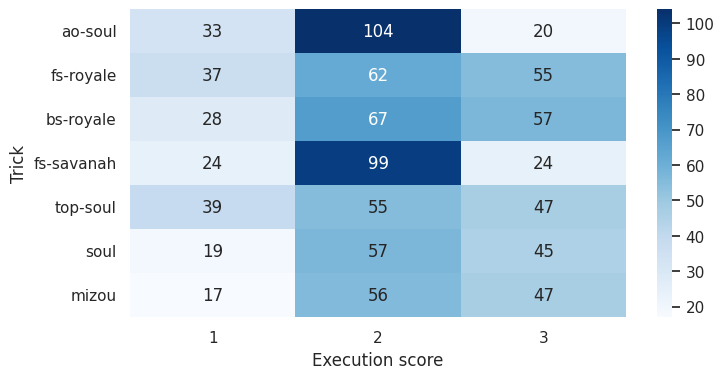

execution_score_label,1,2,3
trick,,,
ao-soul,33,104,20
fs-royale,37,62,55
bs-royale,28,67,57
fs-savanah,24,99,24
top-soul,39,55,47
soul,19,57,45
mizou,17,56,47


In [12]:
trick_score_counts = pd.crosstab(
    score_labels_df["trick"],
    score_labels_df["execution_score_label"],
).reindex(index=trick_order, columns=rating_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, max(4, len(trick_score_counts) * 0.45)))
sns.heatmap(trick_score_counts, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_xlabel("Execution score")
ax.set_ylabel("Trick")
save_plot(fig, "trick_execution_score_heatmap")
plt.show()

display(trick_score_counts)
